In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


=== Run 0 ===

=== Run 1 ===

=== Run 2 ===

=== Run 3 ===

=== Run 4 ===


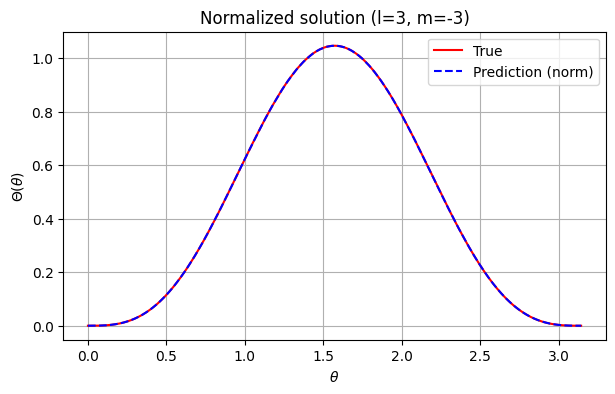

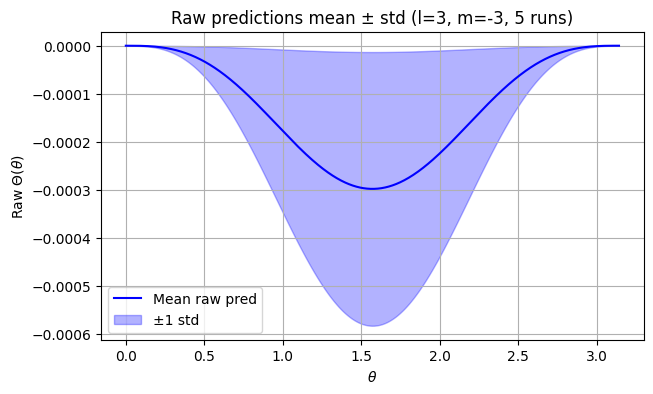

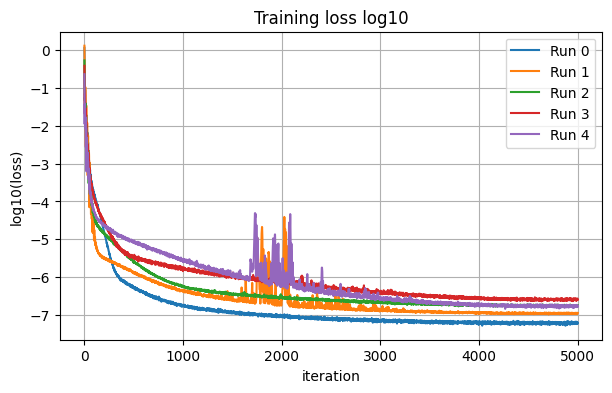

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from scipy.special import lpmv, gamma

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Parameters
l = 3
m = -3   # try +3 to -3
n_runs = 5

n_points_pool = 20000
batch_size = 2048
n_iter = 5000
lr = 1e-4
clip_norm = 5.0

# SIREN-style Network
class SIREN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.linears = nn.ModuleList()
        for i in range(len(layers)-1):
            self.linears.append(nn.Linear(layers[i], layers[i+1]))
        self.act_first = torch.sin
        self.act_hidden = torch.tanh

        with torch.no_grad():
            self.linears[0].weight.uniform_(-1, 1)
            for lin in self.linears[1:]:
                nn.init.xavier_uniform_(lin.weight)
                nn.init.zeros_(lin.bias)

    def forward(self, x):
        x = self.act_first(self.linears[0](x))
        for lin in self.linears[1:-1]:
            x = self.act_hidden(lin(x))
        return self.linears[-1](x)

def embed_theta(theta):
    return torch.cat([torch.sin(theta), torch.cos(theta)], dim=1)

def trial_solution(model, theta, m):
    return (torch.sin(theta) ** abs(m)) * model(embed_theta(theta))

def angular_residual(model, theta, l, m, eps=1e-6):
    theta = theta.clone().requires_grad_(True)
    y = trial_solution(model, theta, m)
    dy = grad(y, theta, grad_outputs=torch.ones_like(y), create_graph=True)[0]
    d2y = grad(dy, theta, grad_outputs=torch.ones_like(dy), create_graph=True)[0]
    sin_theta = torch.sin(theta).clamp(min=eps)
    cot = torch.cos(theta) / sin_theta
    sin2 = sin_theta ** 2
    res = d2y + cot * dy + (l*(l+1) - (m**2)/sin2) * y
    return res

def make_theta_pool(n_points):
    return np.linspace(1e-6, np.pi - 1e-6, n_points)

def train(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = SIREN([2, 256, 128, 128, 128, 1]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_iter)

    theta_pool = make_theta_pool(n_points_pool)
    theta_pool_t = torch.tensor(theta_pool, dtype=torch.float32, device=device).view(-1, 1)

    losses = []
    for itr in range(n_iter):
        idx = torch.randint(0, n_points_pool, (batch_size,), device=device)
        th_batch = theta_pool_t[idx]
        optimizer.zero_grad()
        res = angular_residual(model, th_batch, l, m)
        loss = torch.mean(res**2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

    # LBFGS finetune
    theta_full = theta_pool_t.clone().detach()
    theta_full.requires_grad_(True)
    def closure():
        optimizer_lbfgs.zero_grad()
        res_full = angular_residual(model, theta_full, l, m)
        loss_full = torch.mean(res_full**2)
        loss_full.backward()
        return loss_full
    optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=0.5, max_iter=200, tolerance_grad=1e-8)
    optimizer_lbfgs.step(closure)

    return model, losses, theta_pool

def apply_prefactor(pred, l, m):
    if m >= 0:
        return pred
    else:
        factor = (-1)**abs(m) * gamma(l - abs(m) + 1) / gamma(l + abs(m) + 1)
        return factor * pred

def evaluate(model, theta_grid):
    theta_t = torch.tensor(theta_grid, dtype=torch.float32, device=device).view(-1, 1)
    with torch.no_grad():
        pred = trial_solution(model, theta_t, m).cpu().numpy().flatten()
    pred = apply_prefactor(pred, l, m)
    weights = np.sin(theta_grid)
    norm = np.sqrt(np.trapz(pred**2 * weights, theta_grid))
    return pred, pred / (norm + 1e-16)

def plot_results(theta_grid, preds_raw, preds_norm, all_losses):
    # True normalized solution
    true = lpmv(abs(m), l, np.cos(theta_grid))
    if m < 0:
        factor = (-1)**abs(m) * gamma(l - abs(m) + 1) / gamma(l + abs(m) + 1)
        true = factor * true
    weights = np.sin(theta_grid)
    true /= np.sqrt(np.trapz(true**2 * weights, theta_grid))

    # Representative normalized plot
    pred_norm = preds_norm[0]
    if np.sign(pred_norm[1]) != np.sign(true[1]):
        pred_norm = -pred_norm
    plt.figure(figsize=(7,4))
    plt.plot(theta_grid, true, 'r-', label='True')
    plt.plot(theta_grid, pred_norm, 'b--', label='Prediction (norm)')
    plt.title(f"Normalized solution (l={l}, m={m})")
    plt.xlabel(r'$\theta$'); plt.ylabel(r'$\Theta(\theta)$')
    plt.legend(); plt.grid(True); plt.show()

    # Mean ± std raw predictions
    preds_raw = np.stack(preds_raw, axis=0)
    mean_raw = np.mean(preds_raw, axis=0)
    std_raw = np.std(preds_raw, axis=0)

    plt.figure(figsize=(7,4))
    plt.plot(theta_grid, mean_raw, 'b', label='Mean raw pred')
    plt.fill_between(theta_grid, mean_raw-std_raw, mean_raw+std_raw,
                     color='blue', alpha=0.3, label='±1 std')
    plt.title(f"Raw predictions mean ± std (l={l}, m={m}, {n_runs} runs)")
    plt.xlabel(r'$\theta$'); plt.ylabel(r'Raw $\Theta(\theta)$')
    plt.legend(); plt.grid(True); plt.show()

    # Loss curves
    plt.figure(figsize=(7,4))
    for i, losses in enumerate(all_losses):
        plt.plot(np.log10(np.maximum(losses, 1e-16)), label=f'Run {i}')
    plt.title("Training loss log10")
    plt.xlabel("iteration"); plt.ylabel("log10(loss)")
    plt.legend(); plt.grid(True); plt.show()

if __name__ == "__main__":
    preds_raw, preds_norm, all_losses = [], [], []
    for seed in range(n_runs):
        print(f"\n=== Run {seed} ===")
        model, losses, pool = train(seed=seed)
        pred_raw, pred_norm = evaluate(model, pool)
        preds_raw.append(pred_raw)
        preds_norm.append(pred_norm)
        all_losses.append(losses)

    plot_results(pool, preds_raw, preds_norm, all_losses)